# Stage 3 – EDA, Step 6: Outliers and Unusual Observations

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `04_eda_validity.ipynb` (Step 5)

---

## Where we are in the EDA

Steps 2–5 removed values that are **wrong**: placeholder prices, impossible sizes, contradictory locations and duplicate copies. All of those rules live in `src/cleaning.py`, and the data after them is saved as `data/processed/housing_step5.parquet`: **188,546 distinct listings**.

Step 6 asks a different question. Among the values that are left, which are **unusual**, and are they **errors we missed** or **genuine extremes** that the system should learn from?

This is the last data-quality step. As planned in notebook 01, Steps 1–6 use the **full dataset**, because they are descriptive checks. Step 7 then locks away a test set, and from Step 8 onward every analysis of distributions and relationships uses the **training set only**.

**What Step 6 does not do:** it doesn't study *how* features relate to rent (e.g. "does rent rise with size?"). That's Step 9, on the training data. Doing it here, on data that includes the future test set, would be "data snooping": design choices influenced by the test set.

---

## Background: an outlier is not the same as an error

An **outlier** is a value far from most of the others. An **error** is a value that is wrong. The two overlap, but they are not the same:

| | An error | Not an error |
|---|---|---|
| **An outlier** | 1,100 bedrooms; a \$2.8 billion rent | a \$9,000 penthouse in San Francisco; a 6,000 sq ft house |
| **Not an outlier** | a 2-bed apartment typed as 3-bed | a normal \$1,000 one-bed |

We've already removed the obvious errors (top-left). This step looks at the remaining outliers (top-right) and asks whether any are hidden errors.

**Why this matters for the models.** Genuine extremes affect our five models differently:

- **Linear Regression, k-NN and the MLP are sensitive to extremes.** Linear regression minimises *squared* errors, so one listing that is \$5,000 off counts as much as 25 listings that are \$1,000 off. k-NN measures distances, so one huge value can dominate a distance. The MLP learns by gradient steps, and large inputs make those steps unstable.
- **Random Forest and LightGBM are robust.** Tree models split data at thresholds ("is sqfeet > 1,200?"). Whether the largest value is 5,000 or 50,000 doesn't change where the split goes.

**Three ways to handle a genuine extreme:**

1. **Keep it as is:** fine for tree models.
2. **Transform it:** a log transform pulls in the long right tail (as we decided for `price` in Step 2), so extremes stop dominating.
3. **Cap it (winsorise):** replace values above, say, the 99.5th percentile with the 99.5th percentile. The row stays, but its extreme value is tamed. Any cap must be **learned from the training data only**, inside the preprocessing pipeline.

Deleting genuine extremes is the one option we avoid, because the system should still be able to estimate a \$6,000 house.

**About this version of the notebook:** after the first run, each check is followed by a **"What our data showed"** block with the evidence and the final decision. The confirmed Step 6 rules are now part of `clean_data()` in `src/cleaning.py`, with their limits in `src/utils.py`.

## 6.0 Setup

**What this cell does:** the usual imports and shared helpers, then it loads the data **after Steps 2–5**, saved by notebook 04 as `housing_step5.parquet`. If the file doesn't exist yet (for example, a teammate cloned the project and hasn't run notebook 04), it rebuilds it with `clean_data(..., through_step=5)`.

**Why not the fully cleaned data?** `clean_data()` now also contains the Step 6 rules. This notebook is where those rules were *decided*, so it has to look at the data *before* they're applied. Otherwise the examples in 6.5 and 6.6 would already be gone.

It also creates `log_price = log(1 + price)`, used throughout, and defines two helpers:

- **`peek(mask)`** shows random example listings that match a condition (as in notebook 04);
- **`pct_index(series)`** labels quantile tables as percentages.

In [1]:
# 6.0 Setup

%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import *
from src.cleaning import clean_data
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

if STEP5_FILE.exists():
    dc = pd.read_parquet(STEP5_FILE)
else:
    dc, _ = clean_data(load_raw(), through_step=5)
    dc.to_parquet(STEP5_FILE, index=False)

dc["log_price"] = np.log1p(dc["price"])
print(f"Listings after Steps 2-5 (deduplicated): {len(dc):,}")


SHOW_COLS = ["price", "type", "sqfeet", "beds", "baths", "region", "state", "description"]

def peek(mask, n=8, cols=SHOW_COLS):
    # Random sample of clean listings matching mask, with a shortened description
    n = min(n, int(mask.sum()))
    if n == 0:
        print("   (no listings match)")
        return None
    out = dc.loc[mask, cols].sample(n, random_state=RANDOM_STATE).copy()
    if "description" in out:
        out["description"] = out["description"].str.slice(0, 100)
    with pd.option_context("display.max_colwidth", 110):
        display(out)

def pct_index(series):
    return series.rename(lambda q: f"{q * 100:g}%")

show_obs(5)   # Step 5 findings, to confirm the handover

Listings after Steps 2-5 (deduplicated): 188,546


,step,observation,evidence,decision
0,5-Validity,"sqfeet: 48 zeros, 976 under 100 (typos such as...","5.1 quantiles, threshold counts, repeated valu...","Remove rows with sqfeet outside 100-10,000 (si..."
1,5-Validity,beds 0-8 all plausible (0 = studio); above 8: ...,5.2 value counts and examples,Remove rows with beds > 8
2,5-Validity,"3,107 listings have 0 baths and the examples a...",5.3 value counts and examples,Remove rows with baths outside 0.5-8
3,5-Validity,Under 70 sq ft per room: 114 listings (113 in ...,5.4 consistency checks and examples,Remove both (impossible size/room combinations...
4,5-Validity,Pins outside the U.S.: 262 listings (262 in th...,5.5 bounding-box checks and examples,Blank these coordinates (listing kept) and use...
5,5-Validity,Pins more than 500 km from their region centre...,5.6 haversine distances and examples,Remove: region and pin contradict each other a...
6,5-Validity,14 of 413 Craigslist sites carry two state lab...,5.7 state labels per site,Give each listing its site's most common state...
7,5-Validity,"Sale wording matches 1,794 listings (1,691 in ...",5.8 pattern table and matches in context,No text-based removal rule; remaining sale lis...
8,5-Validity,694 listings priced $100-$249: weekly wording ...,"5.9 wording comparison, price per sq ft, examples",Raise the effective price floor to $250 (RENT_...
9,5-Validity,"Modelling dataset: 384,977 -> 381,800 -> 377,5...",5.10 clean_data() funnel,All rules implemented once in src/cleaning.py;...


## 6.1 How many outliers does the IQR rule find?

**The IQR rule (Tukey's fences)** is the standard way to flag outliers, and it's what box plots draw:

1. Find **Q1** (the 25th percentile) and **Q3** (the 75th percentile). The middle half of the data lies between them.
2. The **interquartile range** is **IQR = Q3 − Q1**, the width of that middle half.
3. A value is an outlier if it's below **Q1 − 1.5 × IQR** (the lower fence) or above **Q3 + 1.5 × IQR** (the upper fence).

It uses quartiles rather than the mean and standard deviation, so the outliers themselves can't distort the fences. That's why it's preferred over the "z-score" rule (more than 3 standard deviations from the mean), which assumes a normal, bell-shaped distribution. Our data isn't normal.

**What this cell does:** it applies the IQR rule to `price`, `sqfeet`, `beds` and `baths`, and, for price and size, **twice**: on the raw values and on the log values. For the log versions it converts the fences back into dollars and square feet so they're easy to read.

**Why both scales?** Rents and sizes are right-skewed: a long tail of large values. On the raw scale, the IQR rule treats the whole natural tail as "outliers" and flags thousands of perfectly ordinary large homes. On the log scale the distribution is roughly symmetric (Step 2 showed log price has skew near 0), so only the truly unusual values are flagged.

**How to read the output:** compare the "flagged" counts between raw and log rows. A big drop on the log scale shows that most raw-scale "outliers" were just the normal skew. For `beds` and `baths`, notice what the fences are. Because these are small whole numbers with most listings at 1–2, the IQR rule may flag every 4-bedroom house as an outlier, which is obviously wrong. That's a known weakness of the IQR rule for **discrete counts**, and a reason to judge by examples rather than by the rule alone.

In [2]:
# 6.1 IQR outlier counts on raw and log scales

def iqr_row(values, name, log_scale=False):
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    to_units = np.expm1 if log_scale else (lambda x: x)
    return {
        "feature": name,
        "lower_fence": to_units(lo),
        "upper_fence": to_units(hi),
        "below": int((values < lo).sum()),
        "above": int((values > hi).sum()),
        "flagged_%": ((values < lo) | (values > hi)).mean() * 100,
    }

iqr_table = pd.DataFrame([
    iqr_row(dc["price"], "price (raw)"),
    iqr_row(dc["log_price"], "price (log scale)", log_scale=True),
    iqr_row(dc["sqfeet"], "sqfeet (raw)"),
    iqr_row(np.log1p(dc["sqfeet"]), "sqfeet (log scale)", log_scale=True),
    iqr_row(dc["beds"], "beds"),
    iqr_row(dc["baths"], "baths"),
]).set_index("feature")

iqr_table.style.format({"lower_fence": "{:,.1f}", "upper_fence": "{:,.1f}",
                        "below": "{:,}", "above": "{:,}", "flagged_%": "{:.2f}%"})

# Fences for the log-scale rows are converted back to dollars / square feet.

,lower_fence,upper_fence,below,above,flagged_%
feature,,,,,
price (raw),-130.0,"2,534.0",0,"9,252",4.91%
price (log scale),369.9,"3,602.3",611,"2,232",1.51%
sqfeet (raw),100.0,"1,860.0",0,"9,558",5.07%
sqfeet (log scale),382.8,"2,380.1","1,853","3,446",2.81%
beds,-2.0,6.0,0,57,0.03%
baths,-0.5,3.5,0,868,0.46%


### 6.1 What our data showed

- **Price:** the IQR rule flags **4.9%** of rents on the raw scale (everything above \$2,534) but only **1.5%** on the log scale (below \$370 or above \$3,602). So more than two-thirds of the raw-scale "outliers" are just the normal right tail of rents.
- **Size:** 5.1% raw vs 2.8% on the log scale (below 383 sq ft or above 2,380 sq ft).
- **Bedrooms:** the fences are −2 to 6, so every 7- and 8-bedroom house (57 listings) is an "outlier". **Bathrooms:** the fences are −0.5 to 3.5, so all **868** homes with 4 or more bathrooms are "outliers". Those are ordinary large houses, which shows why the IQR rule doesn't suit small whole-number counts.

**Decision:** the IQR rule is used to *find* candidates on the log scale, not as a removal rule. No listing is removed because of its IQR status alone.

## 6.2 Box plots on the log scale

**What this cell does:** it draws box plots of price and size on a **log axis**, and of bedrooms and bathrooms as ordinary box plots.

**How to read a box plot:**

- the **box** spans Q1 to Q3 (the middle half of the listings);
- the **line inside** is the median;
- the **whiskers** reach to the furthest points still inside the IQR fences;
- the **dots** beyond the whiskers are the IQR outliers.

For price and size we **take the log of the values first** and then draw the box plot, with the axis labelled back in dollars and square feet. This matters: if you only set a log *axis* on a normal box plot, the box, whiskers and dots are still calculated from the raw values, so the chart would show raw-scale outliers on a log-looking axis. (The first version of this notebook had exactly that bug: its price whisker stopped at the raw fence of about \$2,534.) Computing on the log values makes the whiskers match the log-scale fences in 6.1 (\$370–\$3,602 for price).

On a log scale each step is a multiplication (\$100 → \$1,000 → \$10,000) rather than an addition, so the long right tail no longer squashes the box into a thin line. For beds and baths, look at which whole numbers appear as dots.

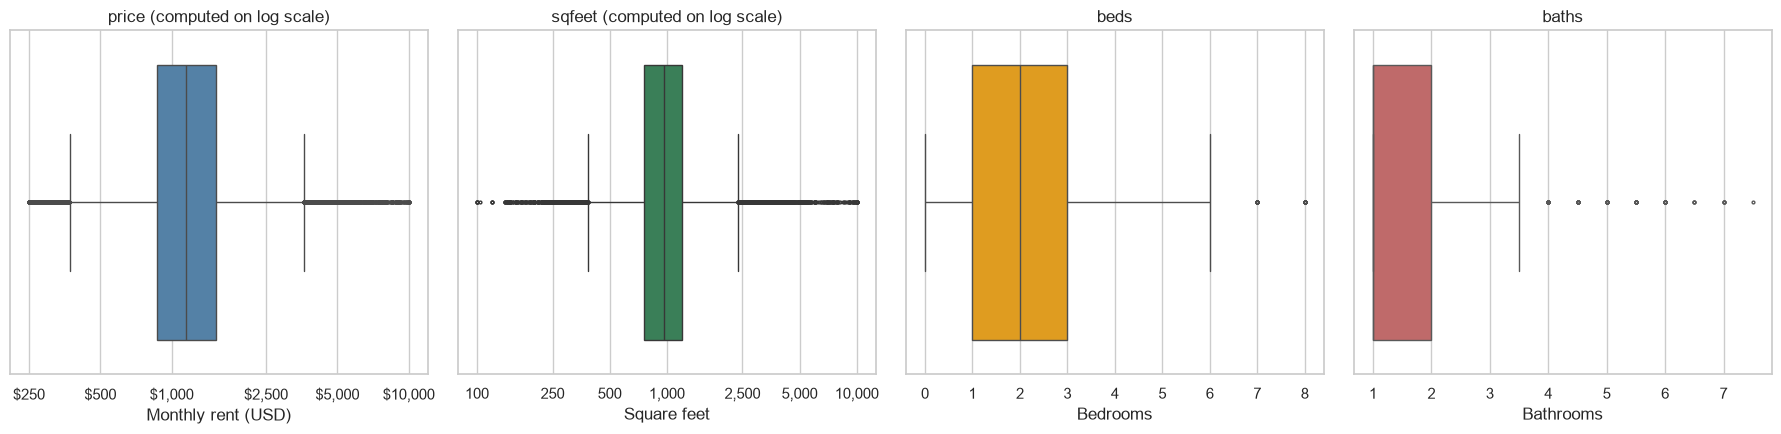

In [3]:
# 6.2 Box plots (price and size computed on log10 values, axis labelled in original units)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

def log_boxplot(ax, values, ticks, title, xlabel, color, fmt):
    sns.boxplot(x=np.log10(values), ax=ax, color=color, fliersize=2)
    ax.set_xticks(np.log10(ticks))
    ax.set_xticklabels([fmt(t) for t in ticks])
    ax.set(title=title, xlabel=xlabel)

log_boxplot(axes[0], dc["price"], [250, 500, 1000, 2500, 5000, 10000],
            "price (computed on log scale)", "Monthly rent (USD)", "steelblue", lambda t: f"${t:,}")
log_boxplot(axes[1], dc["sqfeet"], [100, 250, 500, 1000, 2500, 5000, 10000],
            "sqfeet (computed on log scale)", "Square feet", "seagreen", lambda t: f"{t:,}")

sns.boxplot(x=dc["beds"], ax=axes[2], color="orange", fliersize=2)
axes[2].set(title="beds", xlabel="Bedrooms")

sns.boxplot(x=dc["baths"], ax=axes[3], color="indianred", fliersize=2)
axes[3].set(title="baths", xlabel="Bathrooms")

plt.tight_layout()
save_fig("06_boxplots")
plt.show()

## 6.3 What are the outliers? Reading examples

**What this cell does:** it shows random examples of listings outside the **log-scale** fences: expensive rents, very large homes, and very small homes.

**Why we do it:** the counts in 6.1 only say *how many* listings are unusual. To decide whether they're errors or genuine extremes, we need to look at *what* they are. For each example, ask: **does the rest of the listing fit the unusual value?**

- A \$7,500 rent for a 3,500 sq ft, 4-bed house in the SF Bay Area fits together: a **genuine extreme**.
- A \$7,500 rent for a 600 sq ft 1-bed in rural Ohio doesn't fit: a **likely error**.
- A 150 sq ft listing described as a "micro studio" in Seattle fits. The same size described as a "spacious 2-bedroom" does not.

**How to read the output:** if most examples fit together, the outliers are genuine and should be kept (and handled by a log transform). If many don't fit, there's a hidden error type that needs a rule, which is what 6.5 checks systematically.

In [4]:
# 6.3 Examples of outliers on the log scale

def log_fences(values):
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lp_lo, lp_hi = log_fences(dc["log_price"])
ls_lo, ls_hi = log_fences(np.log1p(dc["sqfeet"]))
log_sqft = np.log1p(dc["sqfeet"])

print(f"Expensive rents (above ${np.expm1(lp_hi):,.0f})")
peek(dc["log_price"] > lp_hi)
print(f"Very large homes (above {np.expm1(ls_hi):,.0f} sq ft)")
peek(log_sqft > ls_hi)
print(f"Very small homes (below {np.expm1(ls_lo):,.0f} sq ft)")
peek(log_sqft < ls_lo)

Expensive rents (above $3,602)


,price,type,sqfeet,beds,baths,region,state,description
161238,4500,duplex,2600,5,3.00,kennewick-pasco-richland,wa,Newly Furnished Homes for 2019: Richland and Kennewick ~Fully furnished with all NEW linens and f
100778,4000,house,2598,3,3.00,santa fe / taos,nm,We are about to purchase a home and need a couple/family to take over our lease on this stunningly b
5635,4980,apartment,1305,3,2.00,SF bay area,ca,"Greendale Apartments, managed by On-Site Management 1200 Dale Ave Mountain View, CA 94040 show cont"
6375,3943,apartment,752,1,1.00,SF bay area,ca,Call Now - show contact info x 22OR Text 22 to show contact info for more information. This is a
40083,4050,apartment,1322,3,2.00,hawaii,hi,"Rarely Available! Large 1,322 sq ft unit (3BR/2BA + spacious den) with two parking in one of Honol"
40419,5200,condo,1520,3,2.00,hawaii,hi,Come home to this fully-furnished Diamond Head/ Ocean corner 3-bedroom unit at the Symphony Honolulu
4393,6250,house,2384,3,2.50,santa barbara,ca,detached garage The home sits on a 9583 sq. ft. lot at the end of a quiet cul-de-sac in the desira
5268,3975,apartment,887,1,1.00,SF bay area,ca,"Located on 3,000+ ft of natural California shoreline in beautiful Redwood City, Blu Harbor is a one-"


Very large homes (above 2,380 sq ft)


,price,type,sqfeet,beds,baths,region,state,description
14957,1500,house,2700,5,2.00,high rockies,co,"Rent Reduced To Welcome Your Dogs, Kids, & Motorcycles Tired of just getting comfortable...then tol"
3581,4299,house,2448,3,2.50,san diego,ca,RESORT-LIKE! UNBELIEVABLE VIEW HOME! YOU MUST SEE TO BELIEVE! SHOWS LIKE A PENTHOUSE in La Costa Gre
34794,1000,house,2621,3,2.00,albany,ga,"Great Craftsman Bungalow located on the Main Street of the Historic District. Close to shopping, res"
86945,2400,house,2400,3,2.50,asheville,nc,Newly renovated 3 bedroom 2.5 bath bungalow within walking distance to Biltmore Village! Completely
79985,1875,house,2640,4,2.00,minneapolis / st paul,mn,"Large Newly Updated Home 4 Bed /2 BathBig Lake, MN 55309 $1,875/mo. KEY FEATURES Year Built: 2004 Sq"
105449,1800,apartment,3000,5,3.00,rochester,ny,Enjoy breathtaking views of Conesus Lake from our 80 feet of waterfront property. 5 bedroom 2 bath
9621,1845,house,2800,2,2.00,boulder,co,"2 BR, 1.75 bath, ranch style house in Berthoud 625 Pyramid Peak Property Address 625"
11269,1185,condo,2398,5,2.50,colorado springs,co,"Completely renovated 4 BR, 1.5 bath brick front colonial features newer siding, windows, entry way,"


Very small homes (below 383 sq ft)


,price,type,sqfeet,beds,baths,region,state,description
22411,1044,apartment,280,0,1.00,gainesville,fl,Furnished Studio - Only 2 Month Minimum!Take advantage of our special discounted rate! All utilities
40715,1595,apartment,324,0,1.00,hawaii,hi,"This is a Studio, 1 Bath Our community is where Lifestyle Meets Location. Perfectly situated in th"
126577,275,apartment,350,2,1.00,poconos,pa,All rooms equipped with microwave and refrigerator; There are suites with kitchen and stove. Larger
174789,1169,apartment,341,0,1.00,phoenix,az,ÅLiv Tempe is designed from the ground up to support the aspirations of our residents. Pursue your
39825,1100,house,300,0,1.00,hawaii,hi,Cozy studio on the lower level of a newly renovated home occupied by a young professional couple off
136833,1005,apartment,364,0,1.00,memphis,tn,"Discover ReNew Riverview Rising 25 stories high in the downtown Memphis sky, Renew Riverview Apartme"
162945,1095,apartment,164,0,1.00,seattle-tacoma,wa,"Living in the city can be expensive, but this property is the perfect fit! You are walking distance"
125386,1080,apartment,352,0,1.00,philadelphia,pa,Experience More Cheer at Stonegate at Devon! Lease Today & Be Home for the Holidays! Stonegate at


### 6.3 What our data showed

In every group, the rest of the listing **fits** the unusual value:

- **Expensive rents (above \$3,602)** are in the SF Bay Area, Hawaii and Santa Barbara, with sizes and descriptions to match, for example a \$6,250 house on a 9,583 sq ft lot in Santa Barbara, or a furnished Diamond Head 3-bed in Honolulu at \$5,200.
- **Large homes (above 2,380 sq ft)** are 3–5 bedroom houses with ordinary rents for their area.
- **Small homes (below 383 sq ft)** are almost all **studios** (0 beds) in cities: a 164 sq ft micro-studio in Seattle, studios in Honolulu and downtown Memphis. The one exception in the sample is a \$275 motel "suite" in the Poconos. Its price per sq ft (\$0.79) passes 6.5, so a few such listings remain as noise.

**Decision:** these are **genuine extremes**, so they're kept.

## 6.4 Extremes within each state

**The idea:** "expensive" depends on *where*. A \$4,000 rent is ordinary in San Francisco but extraordinary in rural Mississippi. The national IQR fences in 6.1 ignore this, so they'll flag many normal California and New York listings, while a suspicious \$2,800 listing in a cheap state slips through.

**What this cell does:**

1. It calculates IQR fences on log price **separately for each state**, using only that state's listings.
2. It compares the two views:
   - **nationally high:** above the national fence;
   - **high for its state:** above its own state's fence.
3. It shows which states hold most of the nationally-high listings, and what share of each state's listings they are.
4. It shows examples of the two interesting groups: nationally high but normal for their state, and normal nationally but high for their state.

**How to read the output:**

- If most nationally-high listings are in expensive states (California, New York, Massachusetts, Hawaii, D.C.) and are *not* high for their own state, they're **genuine**: expensive markets, not errors.
- Listings that are **high for their state but not nationally** are worth a look. In a cheap state, an unusually high rent can be a genuine luxury home *or* a hidden error, and the examples will tell.

**A caution:** states with few listings (e.g. Wyoming) have unstable fences, so their within-state results shouldn't be over-interpreted. The table shows each state's listing count for this reason.

In [5]:
# 6.4 National vs within-state price outliers

state_q = dc.groupby("state")["log_price"].quantile([0.25, 0.75]).unstack()
state_iqr = state_q[0.75] - state_q[0.25]
state_hi = (state_q[0.75] + 1.5 * state_iqr)

nationally_high = dc["log_price"] > lp_hi
state_high = dc["log_price"] > dc["state"].map(state_hi)

cross = pd.crosstab(nationally_high.map({True: "nationally high", False: "not nationally high"}),
                    state_high.map({True: "high for its state", False: "normal for its state"}),
                    rownames=["national view"], colnames=["within-state view"])
display(cross.style.format("{:,}"))

by_state = pd.DataFrame({
    "listings": dc["state"].value_counts(),
    "nationally_high": nationally_high.groupby(dc["state"]).sum(),
    "median_rent": dc.groupby("state")["price"].median(),
    "state_upper_fence_$": np.expm1(state_hi),
})
by_state["nationally_high_%"] = by_state["nationally_high"] / by_state["listings"] * 100
print("States holding the most nationally-high rents")
display(by_state.sort_values("nationally_high", ascending=False).head(10).style.format({
    "listings": "{:,}", "nationally_high": "{:,}", "median_rent": "${:,.0f}",
    "state_upper_fence_$": "${:,.0f}", "nationally_high_%": "{:.1f}%"}))

share_top5 = by_state["nationally_high"].nlargest(5).sum() / nationally_high.sum() * 100
print(f"The top 5 states hold {share_top5:.0f}% of all nationally-high rents")

print("\nNationally high, but normal for their state")
peek(nationally_high & ~state_high)
print("Normal nationally, but high for their state")
peek(~nationally_high & state_high)

within-state view,high for its state,normal for its state
national view,,
nationally high,993,"1,239"
not nationally high,"1,882","184,432"


States holding the most nationally-high rents


,listings,nationally_high,median_rent,state_upper_fence_$,nationally_high_%
state,,,,,
ca,"18,965","1,228","$1,854","$5,408",6.5%
fl,"14,513",117,"$1,219","$2,857",0.8%
ny,"6,598",115,"$1,185","$3,924",1.7%
ma,"2,856",108,"$1,768","$5,114",3.8%
co,"6,180",97,"$1,499","$3,129",1.6%
hi,"1,484",95,"$1,999","$5,410",6.4%
wa,"4,240",81,"$1,495","$3,783",1.9%
dc,"1,833",54,"$1,780","$3,868",2.9%
il,"4,863",47,$950,"$3,309",1.0%


The top 5 states hold 75% of all nationally-high rents

Nationally high, but normal for their state


,price,type,sqfeet,beds,baths,region,state,description
5774,4021,apartment,1073,2,2.00,SF bay area,ca,"Welcome Home! Positioned in the heart of Silicon Valley, Highland Gardens offers its residents the c"
4815,3760,apartment,1100,2,2.00,SF bay area,ca,Youtube sample video https://www.youtube.com/watch?v=O3uoMRoPpXA Come home to country beauty tucke
5259,3750,flat,1250,2,1.00,SF bay area,ca,"This flat is a high ceiling original Edwardian unit with Walnut trims / doors, original hardwood flo"
18314,3780,apartment,912,2,2.00,"washington, DC",dc,To schedule a tour We now book our tour appointments online! Please call or text us at show contac
3833,4000,house,1740,5,2.00,san luis obispo,ca,"Property Address: 234 Ferrini Road, San Luis Obispo CA 93405 PLEASE DO NOT DISTURB OCCUPANTS! We"
5832,4150,apartment,1071,2,2.00,SF bay area,ca,"Hearth CALL US: show contact info x768 Â Plan 2E 2 Â bed / 2 bath / 1071 Sq.Ft / $4,150 - $4,414"
185501,4950,townhouse,2381,3,3.50,monterey bay,ca,"(RYUED) San Carlos Agency, Inc. offers this three bedroom, three and a half bath standalone (no shar"
4756,4965,apartment,739,2,1.00,SF bay area,ca,"Up to 4 Weeks Free!Welcome to The LandingAt The Landing apartments, thereâs an effortlessness here"


Normal nationally, but high for their state


,price,type,sqfeet,beds,baths,region,state,description
134674,2499,apartment,2527,3,3.50,chattanooga,tn,"NOW LEASING:Cottage 824 Sq Ft.: 2527 Beds: 3 Baths: 3.5 Special Features: Attached Garage, Bonus roo"
115710,1695,house,1954,3,2.00,oklahoma city,ok,Don't miss out on this Deer Creek Schools home. Its well kept and has a lot of extras you won't find
77344,2985,townhouse,1200,3,1.50,port huron,mi,"Immaculate completely furnished 3 BR, 1.5 Bath, attached garage townhouse in quiet Pt. Huron Twp. T"
72607,2400,house,2500,4,2.50,detroit metro,mi,This is a 4 bed house with attached garage. It's close to high way 75 and big beaver. 15mins to Oakl
71000,2800,house,2238,3,2.50,ann arbor,mi,"Cathedral ceilings in living and family rooms, Entryway closet, Chic updates throughout, gas firepla"
49371,2200,house,1800,3,2.00,fort wayne,in,"Great for a family or roommates, this 3 bedroom, 2 bath home is in mint condition. This home is loca"
21103,3100,apartment,1075,3,2.00,florida keys,fl,"Life in Key West is just as it seems: relaxed yet vibrant, and utterly exceptional. Thereâs a kin"
121468,2895,duplex,1850,4,2.00,portland,or,"See better photos and SCHEDULE A SHOWING at:http://showinghotline.com/lc/efc7ccb0b1No, it's not a hy"


### 6.4 What our data showed

**2,232 listings are nationally high, and California alone holds 1,228 of them (55%).** The top five states (CA, FL, NY, MA, CO) hold 75%. The states with the highest *share* of nationally-high rents are California (6.5%) and Hawaii (6.4%), the two most expensive rental markets in the data.

**1,239 of the nationally-high listings (56%) are normal for their own state.** The examples are ordinary 2-bed apartments in Silicon Valley at \$3,750–\$4,150, and a Washington, D.C. 2-bed at \$3,780. They're "outliers" only if you ignore location.

**1,882 listings are normal nationally but high for their state.** The examples are larger or better homes in cheaper markets: a 4-bed house in the Detroit suburbs at \$2,400, a 3-bed in Ann Arbor at \$2,800, a Key West apartment at \$3,100. All plausible.

**Decision:** high rents are overwhelmingly **genuine expensive markets**, so they're kept. The model gets location features (region, state and coordinates), so it can learn that \$4,000 means different things in San Jose and in Oklahoma City. This is also a preview of a Step 9 question: *location is likely to be one of the strongest predictors of rent.*

## 6.5 Price per square foot: catching hidden errors

**The idea:** a price or a size can each look normal on its own, while the **combination** is impossible. Step 5 found one such leftover: a 1-bedroom Boston apartment listed at **9,999 sq ft** for \$1,900. Both numbers pass their own rules, but together they give **\$0.19 per sq ft**, far below any real rent in Boston, or anywhere.

**Price per square foot** (`price / sqfeet`) is how the rental industry compares homes of different sizes, and it's the natural check for this kind of error:

- **very low** (a few cents per sq ft) usually means the **size is too big**: an extra digit, or the lot size typed instead of the home size;
- **very high** usually means the **size is too small** (a digit missing) or the price is for something other than the home.

**What this cell does:** it shows the quantiles of price per sq ft, counts listings below and above several thresholds, and shows the states with the highest and lowest typical values for context. The next cell shows examples.

**Why fixed thresholds and not "unusual for its region"?** It's tempting to flag listings whose price per sq ft is far from their *region's* median. But that median is computed from prices, including those of listings that will end up in the **test set**. Removing rows with it would let test prices influence the cleaning. A **fixed** threshold (for example, "below \$0.25 per sq ft is not a real rent anywhere in the U.S.") is a domain rule, like the \$250–\$10,000 price rule, and learns nothing from the data.

,$ per sq ft
0%,0.05
0.1%,0.19
0.5%,0.29
1%,0.36
5%,0.60
50%,1.17
95%,2.72
99%,3.96
99.5%,4.56
99.9%,6.09


,listings,%
below $0.20,220,0.117%
below $0.25,522,0.277%
below $0.35,"1,786",0.947%
above $5,546,0.290%
above $8,35,0.019%
above $10,13,0.007%


Median $ per sq ft: cheapest states   mo $0.71, ms $0.79, ok $0.82, ks $0.84, sd $0.84
Median $ per sq ft: dearest states    nj $1.67, ma $1.83, ca $2.04, dc $2.09, hi $2.42


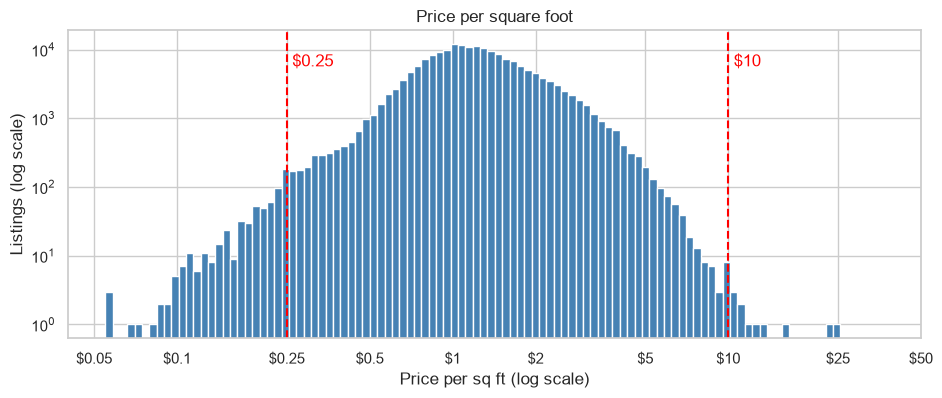

In [6]:
# 6.5 Price per square foot: distribution and threshold counts

ppsf = dc["price"] / dc["sqfeet"]
display(pct_index(ppsf.quantile([0, 0.001, 0.005, 0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999, 1])).rename("$ per sq ft").to_frame())

ppsf_checks = {
    "below $0.20": ppsf < 0.20,
    "below $0.25": ppsf < 0.25,
    "below $0.35": ppsf < 0.35,
    "above $5": ppsf > 5,
    "above $8": ppsf > 8,
    "above $10": ppsf > 10,
}
display(pd.DataFrame({
    "listings": {k: int(m.sum()) for k, m in ppsf_checks.items()},
    "%": {k: m.mean() * 100 for k, m in ppsf_checks.items()},
}).style.format({"listings": "{:,}", "%": "{:.3f}%"}))

state_ppsf = ppsf.groupby(dc["state"]).median().sort_values()
print("Median $ per sq ft: cheapest states  ", ", ".join(f"{s} ${v:.2f}" for s, v in state_ppsf.head(5).items()))
print("Median $ per sq ft: dearest states   ", ", ".join(f"{s} ${v:.2f}" for s, v in state_ppsf.tail(5).items()))

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(np.log10(ppsf), bins=100, color="steelblue")
ax.set_yscale("log")
for x in [0.25, 10]:
    ax.axvline(np.log10(x), color="red", linestyle="--")
    ax.text(np.log10(x) + 0.02, ax.get_ylim()[1] * 0.3, f"${x:g}", color="red")
ticks = [0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10, 25, 50]
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([f"${t:g}" for t in ticks])
ax.set(xlabel="Price per sq ft (log scale)", ylabel="Listings (log scale)", title="Price per square foot")
save_fig("06_price_per_sqft")
plt.show()

### 6.5 (cont.) Examples at both ends

**What this cell does:** it shows examples below \$0.25 per sq ft and above \$10 per sq ft, with the calculated price per sq ft next to each.

**How to decide:** for each example, check whether the description supports the size. "Charming 1-bed apartment" at 9,999 sq ft is clearly an error. "Room in shared house" at 2,000 sq ft (the whole house) for \$400 is a *room* price with a *house* size, which is also unusable as a whole-home rent. A tiny "micro-studio" at \$9 per sq ft in Manhattan could be genuine, which is why the upper limit is set generously.

The limits are **\$0.25 and \$10 per sq ft** (`PPSF_MIN`, `PPSF_MAX` in `utils.py`). They were confirmed from these examples, as explained in the block after this cell.

In [7]:
# 6.5 (cont.) Examples at the extremes, with price per sq ft

dc["ppsf"] = ppsf.round(2)
ppsf_cols = ["price", "sqfeet", "ppsf", "type", "beds", "region", "state", "description"]

print("Below $0.25 per sq ft")
peek(ppsf < 0.25, cols=ppsf_cols)
print("Above $10 per sq ft")
peek(ppsf > 10, cols=ppsf_cols)

bad_ppsf = ~ppsf.between(PPSF_MIN, PPSF_MAX)
print(f"Confirmed rule ${PPSF_MIN}-${PPSF_MAX} per sq ft flags {bad_ppsf.sum():,} listings ({bad_ppsf.mean() * 100:.2f}%)")

Below $0.25 per sq ft


,price,sqfeet,ppsf,type,beds,region,state,description
147454,380,1984,0.19,house,3,lubbock,tx,Welcome Home!! Gorgeous home MOVE IN READY!! New Roof! New Cabinets! New Granite Counter tops! New A
147795,300,2400,0.12,house,1,lubbock,tx,Also free cable including HBO. 2321 13th Street. Private furnished bedroom in women students roomi
14997,769,5600,0.14,apartment,1,high rockies,co,"We are committed to ensure that each guest receives, prompt, professional service. To maintain a cle"
90491,265,1100,0.24,manufactured,3,hickory / lenoir,nc,"$7,000 sales price as is, cash only. All offers are welcomed. Estimated value after renovation $22,0"
49800,376,1956,0.19,house,4,indianapolis,in,Amazing value for a remodeled home. Probably one of the best home. Freshly painted with new Stainles
110671,320,1653,0.19,house,3,cincinnati,oh,"Gorgeous home that has been beautifully updated.There is a huge kitchen with 42-inch cabinets, stain"
187860,650,3100,0.21,house,4,palm springs,ca,Spend the holidays in luxury inside of this beautifully renovated and furnished house in PGA West on
169773,485,1968,0.25,house,4,birmingham,al,"Check out this new 4 bed, 2 bath home in Birmingham!! Check out this new 4 bed, 2 bath home in Birm"


Above $10 per sq ft


,price,sqfeet,ppsf,type,beds,region,state,description
145131,6780,565,12.00,apartment,1,el paso,tx,COME ON IN AND LET THE BEST OF THE BEST SHOW YOU AROUND YOUR NEW MAGNIFICENT COMMUNITY! Office hours
136558,9191,908,10.12,apartment,2,knoxville,tn,Welcome to Hudson on the Greenway! Move in by December 31st and get 1 MONTH FREE RENT PLUS a garage
15034,5500,493,11.16,condo,1,high rockies,co,Le Mazot 5th Ave Condo #13 1 Bedroom/1 Bath Recently Remodeled Unit and Complex 1 block from the
110241,3600,230,15.65,condo,2,cincinnati,oh,"1031 St. Gregory Street #A | Amazing two bedroom two bathroom condo in Mt. Adams - $3,600.00 per mon"
98259,2300,100,23.00,apartment,0,north jersey,nj,High floor studio apartment with a gorgeous view of Manhattan and the Hudson River. About 475sq.ft â
15038,4000,304,13.16,apartment,0,high rockies,co,~ Winfield Arms Unit #18 ~ Location! Location! Location! X -Large Studio / 1 Bathroom + Assigned G
15035,3200,317,10.09,apartment,0,high rockies,co,Winfield Arms Unit #27 Location! Location! Location! Spacious Studio Apartment + 1 Bathroom Desk A
179838,8550,828,10.33,apartment,2,fresno / madera,ca,"Short term leases NOW available! Coaling Station B 250 Truman Avenue, Coalinga, CA, 93210 Use th"


Confirmed rule $0.25-$10 per sq ft flags 535 listings (0.28%)


### 6.5 What our data showed, and the decision

**The typical price per sq ft is \$1.17**, ranging from about \$0.71 in Missouri to \$2.42 in Hawaii. 99.8% of listings fall between \$0.25 and \$10.

**Below \$0.25 (522 listings): every example is something other than a whole-home monthly rent.**

- a **room** price with a whole-house size ("private furnished bedroom in a women students rooming house", \$300 for 2,400 sq ft);
- a **nightly or holiday** rate ("spend the holidays in luxury… PGA West", \$650 for 3,100 sq ft);
- a **sale** ("\$7,000 sales price as is, cash only");
- several 3–4 bedroom houses in Lubbock, Indianapolis and Cincinnati at \$320–\$380, far below any real rent for a whole house in those cities.

**Above \$10 (13 listings): mostly errors, with one genuine exception.**

- **Size typos:** a North Jersey studio entered as 100 sq ft whose description says "about 475 sq ft", and a 2-bed condo in Cincinnati at 230 sq ft.
- **Price errors:** a 1-bed in El Paso at \$6,780, a 2-bed in Knoxville at \$9,191, a 2-bed in Coalinga (CA) at \$8,550. All are several times the local rent.
- **Genuine:** small studios in a Colorado ski resort (the "high rockies" region) at \$3,200–\$5,500. Resort towns really are that expensive, so a handful of real listings is lost. With only 13 listings above \$10, that's an acceptable cost.

**Decision:** keep listings between **\$0.25 and \$10 per sq ft** (`PPSF_MIN`, `PPSF_MAX` in `utils.py`), removing **535 listings (0.28%)**. This is a fixed domain rule. It doesn't learn anything from the data, so applying it before the split is leak-free.

## 6.6 Property types that aren't homes

**What this cell does:** it lists every property type with its number of listings and its share. It then shows the listings of the two types that stood out in Step 1: **`land`** and **`assisted living`**.

**Why we do it:** this project estimates the rent of **residential homes**. A plot of land isn't a home: its "rent" might be for parking a trailer or farming. Assisted living is a care service, where the price includes meals and nursing, not just housing. Even if their prices look normal, they describe a different product, so they teach the model the wrong thing.

**Keeping rare-but-real types is a separate question.** Types like `in-law` (a small unit attached to a house) or `loft` are rare but genuine homes. They are *kept*. Whether the model should group them into an "other" category because they're rare is a decision for the preprocessing stage (Step 8 and the pipeline), where it's made on the training data.

**How to read the output:** if the land and assisted-living examples aren't normal homes (as expected), they're removed. There are only a handful, so the decision costs essentially nothing.

In [8]:
# 6.6 Property types

type_table = dc["type"].value_counts().rename("listings").to_frame()
type_table["share_%"] = type_table["listings"] / len(dc) * 100
display(type_table.style.format({"listings": "{:,}", "share_%": "{:.2f}%"}))

# EXCLUDED_TYPES comes from utils.py
for t in EXCLUDED_TYPES:
    print(f"\nListings of type '{t}'")
    peek(dc["type"].eq(t))

not_a_home = dc["type"].isin(EXCLUDED_TYPES)
print(f"\nNon-home types flag {not_a_home.sum():,} listings")

,listings,share_%
type,,
apartment,"140,181",74.35%
house,"26,912",14.27%
townhouse,"8,220",4.36%
condo,"5,076",2.69%
duplex,"3,991",2.12%
manufactured,"2,472",1.31%
cottage/cabin,617,0.33%
flat,457,0.24%
loft,453,0.24%



Listings of type 'land'


,price,type,sqfeet,beds,baths,region,state,description
100636,550,land,2000,0,1.00,santa fe / taos,nm,"Now Available: Parking Space for tiny house or RV on land out SF Trail, Below Camp Stoney. Adjoins W"
178059,750,land,900,2,1.00,jonesboro,ar,"Hwy 141 @ Craighead/Greene County line. 2 bedroom 1 bath mobile home - partially furnished, or not."
25186,350,land,400,1,1.00,lakeland,fl,"Lake Juliana Boating and Lodging, a 100 year old central Florida fishcamp known to locals as Lundyvi"
152033,500,land,300,2,1.00,tyler / east TX,tx,"Very nice and lots of room in this rv rental with 5 slide outs, sleeps up to six. Perfect for someon"



Listings of type 'assisted living'


,price,type,sqfeet,beds,baths,region,state,description
118045,3400,assisted living,2130,6,2.00,corvallis/albany,or,"Adult Foster Care Home, Purpose Built, Ready for you! Property Address 1715 NW Arthur"



Non-home types flag 5 listings


### 6.6 What our data showed, and the decision

After the earlier cleaning, only **4 `land` listings and 1 `assisted living` listing** remain, and none of them is an ordinary home:

- **land:** a *parking space* for a tiny house or RV, an RV rental "with 5 slide-outs", lodging at a century-old fish camp, and a mobile home on a rural plot;
- **assisted living:** an *adult foster care* home, where the \$3,400 pays for care, not just housing.

**Decision:** remove both types (`EXCLUDED_TYPES`). The rare but genuine home types are kept: `in-law` (162), `loft` (453), `flat` (457) and `cottage/cabin` (617). Whether to group them as "other" is decided on the training data in the preprocessing pipeline.

## 6.7 What happens to the genuine extremes?

After 6.5 and 6.6, what remains are **genuine** unusual listings: large houses, expensive city apartments, big student homes. This section records how they'll be handled. It's a *plan* for the preprocessing pipeline, not something applied here.

**What this cell does:** it shows how much the distribution of each numeric feature is stretched by its most extreme values. It compares the **99th and 99.9th percentiles** to the **maximum**, and computes the **skewness**, both raw and after a log transform.

**How to read the output and the decisions it supports:**

- **Skewness** measures how lopsided a distribution is. 0 means symmetric; above about 1 means a long right tail. If the log transform brings the skewness close to 0, the transform alone is enough to stop the extremes dominating. **No capping is needed**, and no genuine listings lose information.
- If the **maximum is far beyond the 99.9th percentile** even on the log scale, a few extreme values could still pull on the sensitive models, and a **cap at a high percentile** (learned from the training data only) is a reasonable safety net for Linear Regression, k-NN and the MLP.
- **Tree models (Random Forest, LightGBM) get the raw values.** They don't need transforms or caps, so adding them would only make the pipeline more complicated.

In [9]:
# 6.7 How stretched is each feature by its extremes?

rows = []
for col in ["price", "sqfeet", "beds", "baths"]:
    s = dc[col]
    rows.append({
        "feature": col,
        "median": s.median(),
        "99%": s.quantile(0.99),
        "99.9%": s.quantile(0.999),
        "max": s.max(),
        "skew_raw": s.skew(),
        "skew_log1p": np.log1p(s).skew(),
    })
pd.DataFrame(rows).set_index("feature").style.format({
    "median": "{:,.1f}", "99%": "{:,.1f}", "99.9%": "{:,.1f}", "max": "{:,.1f}",
    "skew_raw": "{:.2f}", "skew_log1p": "{:.2f}"})

,median,99%,99.9%,max,skew_raw,skew_log1p
feature,,,,,,
price,"1,150.0","3,800.0","6,500.0","10,000.0",2.73,0.37
sqfeet,970.0,"2,692.5","4,395.1","10,000.0",3.27,0.20
beds,2.0,5.0,6.0,8.0,0.57,-0.58
baths,1.0,3.0,4.5,7.5,1.02,0.54


### 6.7 What our data showed, and the decision

| Feature | Skew (raw) | Skew (log) | Decision |
|---|---|---|---|
| price | 2.73 | 0.37 | Model `log1p(price)` (decided in Step 2); no cap needed |
| sqfeet | 3.27 | 0.20 | Log-transform for the sensitive models; no cap needed |
| beds | 0.57 | −0.58 | **No** log. Only mildly skewed, and the log *creates* a left skew |
| baths | 1.02 | 0.54 | **No** log. A small whole-number count with a short tail |

**Price and size:** the log transform brings both close to symmetric (skew 0.37 and 0.20). The maximum (\$10,000 and 10,000 sq ft) is capped by our own cleaning limits, so no further capping is needed.

**Beds and baths:** these are small whole numbers (0–8), and after cleaning their extremes are only 7–8 bedrooms and 7.5 bathrooms. Taking the log of beds would turn a mild right skew into a left skew (−0.58), so they stay as plain counts. For the sensitive models they're simply **scaled** (standardised) in the pipeline, like every numeric input.

**Tree models (Random Forest, LightGBM)** receive untransformed values, because splits don't depend on scale or skew.

## 6.8 Effect of the Step 6 rules

**What this cell does:** it combines the two removal rules from this step, price per sq ft outside \$0.25–\$10 (6.5) and non-home property types (6.6), and shows how many clean listings they would remove, including any overlap.

**Why:** the same check as the funnel in Step 5. Before adding a rule to `clean_data()`, we confirm it only removes a small, justified share of the data. Both rules have been confirmed from the examples and are now part of `clean_data()` in `src/cleaning.py`, with their limits in `utils.py`, just as Step 5's were.

In [10]:
# 6.8 Combined effect of the Step 6 rules

step6_remove = bad_ppsf | not_a_home
effect = pd.Series({
    "clean listings (after Steps 2-5)": len(dc),
    f"price per sq ft outside ${PPSF_MIN}-${PPSF_MAX}": int(bad_ppsf.sum()),
    "non-home types": int(not_a_home.sum()),
    "flagged by both": int((bad_ppsf & not_a_home).sum()),
    "removed in total": int(step6_remove.sum()),
    "remaining": int((~step6_remove).sum()),
}, name="listings").to_frame()
effect["%_of_clean"] = effect["listings"] / len(dc) * 100
effect.style.format({"listings": "{:,}", "%_of_clean": "{:.2f}%"})

,listings,%_of_clean
clean listings (after Steps 2-5),"188,546",100.00%
price per sq ft outside $0.25-$10,535,0.28%
non-home types,5,0.00%
flagged by both,0,0.00%
removed in total,540,0.29%
remaining,"188,006",99.71%


## 6.9 Log the Step 6 observations

As before, `clear_obs("6")` removes older Step 6 entries, and the numbers are filled in from your results. The wording of the skewness entries is chosen by the code: it says whether the log transform is enough, or whether a cap is also advisable.

In [11]:
# 6.9 Log the observations

clear_obs("6")

raw_p = iqr_table.loc["price (raw)"]
log_p = iqr_table.loc["price (log scale)"]
raw_s = iqr_table.loc["sqfeet (raw)"]
log_s = iqr_table.loc["sqfeet (log scale)"]

log_obs("6-Outliers",
        f"IQR rule flags {raw_p['flagged_%']:.1f}% of prices and {raw_s['flagged_%']:.1f}% of sizes on the raw scale, "
        f"but only {log_p['flagged_%']:.1f}% and {log_s['flagged_%']:.1f}% on the log scale",
        "6.1 IQR table, 6.2 log-scale box plots",
        "Most raw-scale 'outliers' are the natural right skew, not errors; judge outliers on the log scale")

log_obs("6-Outliers",
        f"IQR fences for discrete counts are misleading: beds fences {iqr_table.loc['beds', 'lower_fence']:.1f}-"
        f"{iqr_table.loc['beds', 'upper_fence']:.1f}, baths {iqr_table.loc['baths', 'lower_fence']:.1f}-"
        f"{iqr_table.loc['baths', 'upper_fence']:.1f}, flagging {int(iqr_table.loc['beds', 'above']):,} listings "
        f"for bedrooms and {int(iqr_table.loc['baths', 'above']):,} for bathrooms that are ordinary larger homes",
        "6.1 IQR table",
        "No IQR-based removal for beds/baths; Step 5 limits (0-8 beds, 0.5-8 baths) already remove the errors")

log_obs("6-Outliers",
        f"The top 5 states hold {share_top5:.0f}% of nationally-high rents; "
        f"{int((nationally_high & ~state_high).sum()):,} nationally-high listings are normal for their own state",
        "6.4 national vs within-state fences, examples",
        "High rents are mostly genuine expensive markets: keep them; location features let the model learn this")

log_obs("6-Outliers",
        f"Price per sq ft outside ${PPSF_MIN}-${PPSF_MAX}: {int(bad_ppsf.sum()):,} listings "
        f"({bad_ppsf.mean() * 100:.2f}%), e.g. oversized typos such as a 9,999 sq ft one-bed",
        "6.5 quantiles, threshold counts, examples",
        f"Remove (fixed domain rule, no leakage): room, nightly and sale prices, and size/price typos")

log_obs("6-Outliers",
        f"Non-home property types {EXCLUDED_TYPES}: {int(not_a_home.sum())} listings",
        "6.6 type table and examples",
        "Remove (not residential homes); rare genuine types (in-law, loft, ...) kept, grouping decided in the pipeline")

for col in ["price", "sqfeet"]:
    skew_raw, skew_log = dc[col].skew(), np.log1p(dc[col]).skew()
    verdict = ("log transform is enough; no cap needed" if abs(skew_log) < 0.5
               else "log transform, plus percentile caps at both ends (fitted on training data) for the sensitive models")
    log_obs("6-Outliers",
            f"{col}: skew {skew_raw:.2f} raw vs {skew_log:.2f} after log1p",
            "6.7 skewness table",
            f"Keep genuine extremes; {verdict}; tree models use raw values")

log_obs("6-Outliers",
        f"beds skew {dc['beds'].skew():.2f} raw vs {np.log1p(dc['beds']).skew():.2f} after log1p; "
        f"baths {dc['baths'].skew():.2f} vs {np.log1p(dc['baths']).skew():.2f}",
        "6.7 skewness table",
        "No log transform for beds/baths (small counts; log over-corrects beds); standardise them for the sensitive models")

log_obs("6-Outliers",
        f"Step 6 rules would remove {int(step6_remove.sum()):,} of {len(dc):,} clean listings "
        f"({step6_remove.mean() * 100:.2f}%)",
        "6.8 combined effect",
        "Rules confirmed and added to clean_data() in src/cleaning.py; applied before the Step 7 split")

show_obs(6)

,step,observation,evidence,decision
0,6-Outliers,IQR rule flags 4.9% of prices and 5.1% of size...,"6.1 IQR table, 6.2 log-scale box plots",Most raw-scale 'outliers' are the natural righ...
1,6-Outliers,IQR fences for discrete counts are misleading:...,6.1 IQR table,No IQR-based removal for beds/baths; Step 5 li...
2,6-Outliers,The top 5 states hold 75% of nationally-high r...,"6.4 national vs within-state fences, examples",High rents are mostly genuine expensive market...
3,6-Outliers,Price per sq ft outside $0.25-$10: 535 listing...,"6.5 quantiles, threshold counts, examples","Remove (fixed domain rule, no leakage): room, ..."
4,6-Outliers,"Non-home property types ['land', 'assisted liv...",6.6 type table and examples,Remove (not residential homes); rare genuine t...
5,6-Outliers,price: skew 2.73 raw vs 0.37 after log1p,6.7 skewness table,Keep genuine extremes; log transform is enough...
6,6-Outliers,sqfeet: skew 3.27 raw vs 0.20 after log1p,6.7 skewness table,Keep genuine extremes; log transform is enough...
7,6-Outliers,beds skew 0.57 raw vs -0.58 after log1p; baths...,6.7 skewness table,No log transform for beds/baths (small counts;...
8,6-Outliers,"Step 6 rules would remove 540 of 188,546 clean...",6.8 combined effect,Rules confirmed and added to clean_data() in s...


---

## Step 6 – Summary of findings

| Finding | Evidence | Decision |
|---|---|---|
| The IQR rule flags 4.9% of rents and 5.1% of sizes on the raw scale, but 1.5% and 2.8% on the log scale | 6.1, 6.2 | Most raw "outliers" are the natural skew; judge on the log scale |
| For beds and baths, the IQR rule flags ordinary large homes (every home with 4+ bathrooms) | 6.1 | No IQR-based removal for counts |
| Log-scale outliers (expensive city rents, big houses, city micro-studios) are consistent with the rest of their listing | 6.3 | Genuine extremes: keep |
| California holds 55% of nationally-high rents; 56% of nationally-high listings are normal for their own state | 6.4 | High rents are genuine markets; location features handle them |
| Below \$0.25/sq ft: rooms, nightly rates, sales and wrong prices. Above \$10/sq ft: mostly size or price typos | 6.5 | Keep \$0.25–\$10 per sq ft; removes 535 listings (0.28%) |
| 4 `land` listings (RV lots, a fish camp) and 1 `assisted living` (adult foster care) | 6.6 | Remove non-home types |
| Log brings price and size near symmetric (skew 0.37, 0.20); beds and baths are short-tailed counts | 6.7 | Log price and size for sensitive models; beds/baths scaled only; trees use raw values; no caps |

**How to explain Step 6 in one paragraph:** most "outliers" in rental data aren't errors. They're expensive markets and big houses, and they're exactly what the system should learn to price. We therefore judged outliers on the log scale and *within each state*, removed only the listings whose price per square foot showed they weren't whole-home monthly rents (0.28%), and handled the genuine extremes with a log transform rather than deletion or capping.

---

## What's next: Step 7 – The train/test split (`06_split.ipynb`)

This notebook finishes the **data-quality phase** (Steps 1–6). With the Step 6 rules added to `clean_data()`, the cleaning is final, and Step 7 will:

- split it into **80% training / 20% test**, **stratified** on the log-price deciles from Step 2, so both sets have the same mix of cheap and expensive rentals;
- save both sets to `data/processed/` and lock the test set away.

From Step 8 onward, every chart of distributions and every analysis of how features relate to rent uses the **training set only**, as set out in the plan in notebook 01.